<a href="https://colab.research.google.com/github/yishiliu203/ACS-WILDA-Team7-Customer-Churn/blob/Predictive_Modelling/final_predictive_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
#Import required libraries
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

In [31]:
# Load dataset
df = pd.read_csv("dataset_with_clusters.csv")

In [32]:
# Separate features (X) and target (y)
X = df.drop(columns=["Churn"])   # all columns except target
y = df["Churn"]                 # target variable

In [33]:
# Perform Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # IMPORTANT: keeps churn distribution balanced
)

In [34]:

# Check shapes
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5634, 11)
Testing set: (1409, 11)


In [35]:
# Check distribution
print("\nChurn distribution in training set:")
print(y_train.value_counts(normalize=True))


Churn distribution in training set:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


In [36]:
print("\nChurn distribution in testing set:")
print(y_test.value_counts(normalize=True))


Churn distribution in testing set:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [37]:
# Combine X and y back together for saving
train_data = X_train.copy()
train_data["Churn"] = y_train
test_data = X_test.copy()
test_data["Churn"] = y_test

In [38]:
# Save to CSV files
train_data.to_csv("train_data.csv", index=False)
test_data.to_csv("test_data.csv", index=False)

In [39]:
print("Train and Test datasets saved successfully!")

Train and Test datasets saved successfully!


In [40]:
# Feature Scaling

# Create scaler object
scaler = StandardScaler()

In [41]:
# Columns to scale
num_cols = ["tenure", "MonthlyCharges"]

In [42]:
# Fit ONLY on training data, transform both
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [43]:
#Scaling numerical values
print(X_train[["tenure", "MonthlyCharges"]].head())
print()
print("Means:")
print(X_train[["tenure", "MonthlyCharges"]].mean())
print()
print("Standard deviations:")
print(X_train[["tenure", "MonthlyCharges"]].std())

        tenure  MonthlyCharges
3757 -1.276682       -0.149881
3165 -0.096089       -0.315125
4912  0.555273        1.172071
3877  0.433143        0.048412
3818 -1.276682       -1.471834

Means:
tenure           -3.152923e-18
MonthlyCharges   -1.513403e-17
dtype: float64

Standard deviations:
tenure            1.000089
MonthlyCharges    1.000089
dtype: float64


In [44]:
# Check result
print(X_train.head())

      gender  SeniorCitizen  Dependents    tenure  PhoneService  \
3757       1              0           1 -1.276682             1   
3165       0              0           0 -0.096089             1   
4912       0              1           0  0.555273             1   
3877       1              0           0  0.433143             1   
3818       1              0           0 -1.276682             1   

      MultipleLines  MonthlyCharges  InternetService_Fiber optic  \
3757              0       -0.149881                        False   
3165              0       -0.315125                        False   
4912              1        1.172071                         True   
3877              0        0.048412                        False   
3818              1       -1.471834                         True   

      Contract_One year  Contract_Two year  Cluster  
3757              False               True        2  
3165               True              False        1  
4912              False   

In [45]:
# Build ANN model
model = Sequential([
    Dense(256, activation="elu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation="elu"),
    BatchNormalization(),
    Dropout(0.25),

    Dense(64, activation="elu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation="elu"),
    Dropout(0.15),

    Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [47]:
# Show model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,073 (183.88 KB)

 Trainable params: 46,177 (180.38 KB)

 Non-trainable params: 896 (3.50 KB)

In [48]:
print(X_train.shape)
print(X_train.columns)

(5634, 11)
Index(['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService',
       'MultipleLines', 'MonthlyCharges', 'InternetService_Fiber optic',
       'Contract_One year', 'Contract_Two year', 'Cluster'],
      dtype='object')


In [56]:
#Train the model

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight={0:1, 1:2}  #added weightage
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7657 - loss: 0.6456 - val_accuracy: 0.7578 - val_loss: 0.4668
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7610 - loss: 0.6449 - val_accuracy: 0.7631 - val_loss: 0.4620
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7639 - loss: 0.6471 - val_accuracy: 0.7374 - val_loss: 0.4902
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7575 - loss: 0.6502 - val_accuracy: 0.7391 - val_loss: 0.4928
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7641 - loss: 0.6473 - val_accuracy: 0.7445 - val_loss: 0.4771
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7644 - loss: 0.6510 - val_accuracy: 0.7622 - val_loss: 0.4764
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7666 - loss: 0.6481 - val_accuracy: 0.7542 - val_loss: 0.4739
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7626 - loss: 0.6484 - val_accuracy: 0.

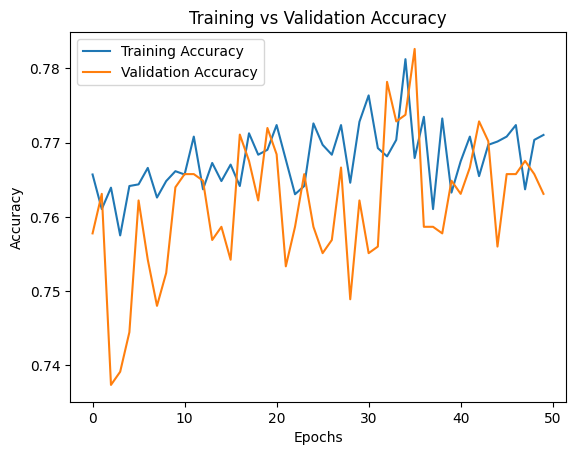

In [57]:
#Training accuracy vs Validation accuracy
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

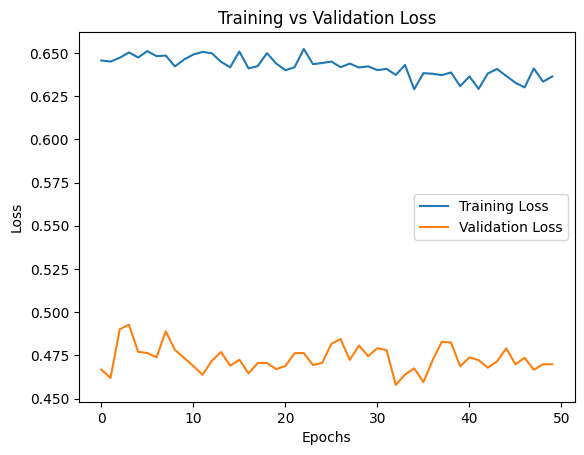

In [58]:
#Loss curve plot
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [59]:
#Evaluate test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7630 - loss: 0.4928
Test Accuracy: 0.762952446937561
Test Loss: 0.4927925169467926


In [60]:
#Model Performance
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.55).astype(int) #prediction threshold changed to 0.4

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[864 171]
 [152 222]]
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1035
           1       0.56      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409



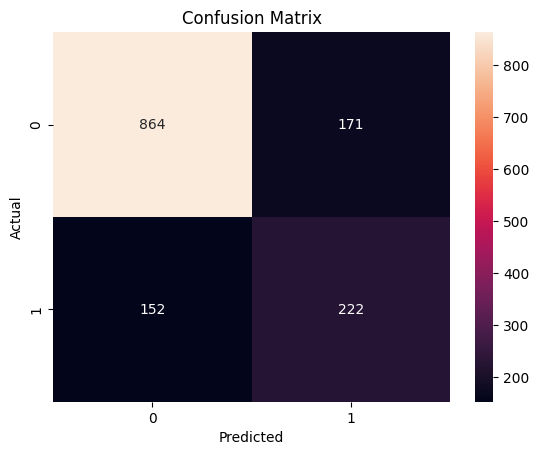

In [61]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

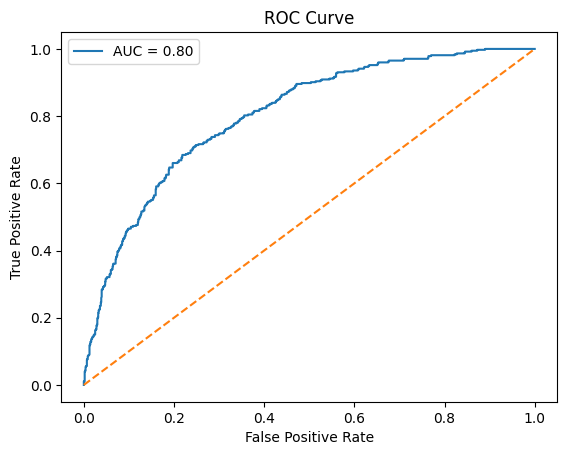

In [62]:
#ROC Curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()